In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

from sklearn.preprocessing import MinMaxScaler

import scipy.stats

/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?


In [3]:
# import sys
# sys.path.append('../notebooks')
# import unifying_algo_analysis_helper as uaah

# Helper functions

In [ ]:
from splitflow.affine_math_and_plot_helper import *

# Hyper parameters

In [5]:
RANDOMNESS = False

FIGURE_NAME = 'unifying_math.svg'

# 
SPEED = 0.3

UPWIND_GAMMA_MULTIPLIER = 0

UPWIND_TRANSLATION_MULTIPLIER = 0.2

SACCADE_THRESHOLD_PROPORTIONAL = 8
SACCADE_THRESHOLD_DERIVATIVE = 3

SMOOTHING_WINDOW = 11

SLOPE_STD = 0.3

dt = 0.01

# Rerun this notebook for all three options:

stillair, laminar, unsteady

In [6]:
scenario = 'laminar'

t, wind_direction, wind_speed = get_wind(scenario, RANDOMNESS=True, SMOOTHING_WINDOW=SMOOTHING_WINDOW, dt=dt)
raw_circle_course = get_circle_basis(t, RANDOMNESS)
axis_ratio = get_axis_ratio(wind_direction, wind_speed)
color = get_color(scenario)

In [7]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

### Plot the wind time series

In [8]:
ax = layout.axes[(scenario, 'wind')]

#####################################################################################################
# Wind
wind_direction_shifted = wrap_angle(wind_direction, midangle='pi')+np.pi
ax.scatter(t, wind_direction_shifted, s=2, c=wind_speed, cmap='plasma', vmin=0, vmax=0.6, zorder=-1)

ax.set_ylim(0, 2*np.pi)

xticks = [0, 1, 2, 3, 4, 5]
xticklabels = np.array(xticks)
ax.set_xlim(0, 5)
ax.set_xticks(xticks)
ax.set_xticklabels([])

ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

if scenario == 'stillair':
    ax.set_yticklabels(['$0$', '', '', '', '$2\pi$'])
    ax.tick_params(axis='y', pad=2)
    ax.tick_params(axis='x', pad=2)
else:
    ax.set_yticklabels([])

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

ax.set_rasterization_zorder(0)

### Get affine warped course

In [9]:
raw_circle_xy = get_circle_xy(raw_circle_course)

affine_trans_warped_course_angle, affine_trans_warped_circle_xy, mean_affine_trans_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=UPWIND_TRANSLATION_MULTIPLIER*(1-axis_ratio)
                                                                                                                  )



In [10]:
affine_warped_course_angle, affine_warped_circle_xy, mean_affine_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                  )



### Plot circle and affine transform

In [11]:
ax = layout.axes[(scenario, 'ellipse')]
ax.set_aspect('equal')

# plot raw circle
ax.plot(raw_circle_xy[0,0:160], raw_circle_xy[1,0:160], '--', color='blue', linewidth=0.5)

# Plot the affine transform
#ax.plot(affine_warped_circle_xy[0,:], affine_warped_circle_xy[1,:], color=color, linewidth=0.5)
ax.plot(mean_affine_trans_warped_circle_xy[0,:], mean_affine_trans_warped_circle_xy[1,:], color=color, linewidth=1)

ax.set_ylim(-1.1, 1.1)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [12]:
# cvx_warped_course_angle, cvx_warped_circle_xy = get_upwind_biased_trajec_cvx(wind_direction, axis_ratio, affine_warped_course_angle, 
#                                                                              UPWIND_GAMMA_MULTIPLIER,
#                                                                              SMOOTHING_WINDOW, SPEED, RANDOMNESS=False)
# x, y = get_trajec(cvx_warped_course_angle, dt, SPEED, RANDOMNESS=False)

### Plot upwind biased trajec

In [13]:
x, y = get_trajec(affine_trans_warped_course_angle, dt, SPEED)

In [14]:
#####################################################################################################
# Goal C
ax = layout.axes[(scenario, 'trajec1')]
ax.set_aspect('equal')

orig_traj = np.vstack((x, y)).T
orig_traj = MinMaxScaler().fit_transform(orig_traj)
braid_analysis_plots.plot_arrowhead_trajectory(orig_traj[:,0], orig_traj[:,1], color='black', linewidth=0.5, ax=ax, arrow_length=0.12)

fifi.mpl_functions.adjust_spines(ax, [])

### Plot upwind biased cvx course

In [15]:
ax = layout.axes[(scenario, 'course1')]
plot_course(ax, t, raw_circle_course, affine_warped_course_angle, affine_trans_warped_course_angle, 
            colors=['blue', 'magenta', color],
                show_labels=False)
set_selective_rasterization(ax, 
                            rasterize_markers=['.'], 
                            rasterize_collections=[mcollections.PathCollection, 
                                                   mcollections.PolyCollection], 
                            raster_zorder=-1)

if scenario == 'stillair':
    ax.set_yticklabels(['$-\pi$', '', '', '', '$\pi$'])
    ax.set_xticklabels(['$0$', '', '', '', '', '$5$'])

### Get upwind bias with saccadic trajectory

In [16]:
staircase_warped_course_angle = get_upwind_biased_trajec_saccade(wind_direction, axis_ratio, affine_warped_circle_xy, 
                                                                 dt,
                                                                 UPWIND_GAMMA_MULTIPLIER,
                                                                 SMOOTHING_WINDOW, SPEED, 
                                                                 SACCADE_THRESHOLD_PROPORTIONAL, SACCADE_THRESHOLD_DERIVATIVE,
                                                                 )

In [17]:
x, y = get_trajec(staircase_warped_course_angle, dt, SPEED)

### Plot the saccadic trajectory

In [18]:
# ax = layout.axes[(scenario, 'trajec2')]
# ax.set_aspect('equal')

# orig_traj = np.vstack((x, y)).T
# orig_traj = MinMaxScaler().fit_transform(orig_traj)
# braid_analysis_plots.plot_arrowhead_trajectory(orig_traj[:,0], orig_traj[:,1], color='black', linewidth=0.5, ax=ax, arrow_length=0.12)

# fifi.mpl_functions.adjust_spines(ax, [])

### Plot the saccadic course

In [19]:
# ax = layout.axes[(scenario, 'course2')]
# plot_course(ax, t, raw_circle_course, affine_warped_course_angle, staircase_warped_course_angle, 
#                 show_labels=False)

### Write to SVG

In [20]:
layout.append_figure_to_layer(layout.figures[scenario], scenario, cleartarget=True)
layout.write_svg(FIGURE_NAME)

### Display SVG

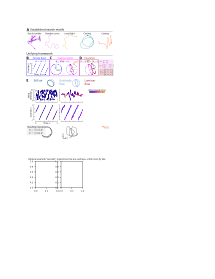

In [21]:
from IPython.display import display,SVG
display(SVG(FIGURE_NAME))